In [ ]:
import os 
import gc

import torch
from torch.utils.data import DataLoader, random_split
from torch.optim import AdamW
from copy import deepcopy

from tqdm.auto import tqdm

import matplotlib.pyplot as plt

import sqlite3
import pandas as pd

import subprocess
from datetime import datetime

from ipywidgets import widgets
from IPython.display import display

import time

from typing import cast

import json

from pathlib import Path
import sys

ROOT = Path.cwd().parents[1]
sys.path.append(str(ROOT))

from src.config.paths import EMBEDS_DIR, RESULTS, DB_PATH, MODELS
from src.data.types import DinoModel
from src.fine_tune.utils import get_device

EMBED_PATH = EMBEDS_DIR/ ""
EMBED_NAME = EMBED_PATH.stem

RESULTS_DIR = RESULTS / EMBED_NAME

MODEL_DIR = MODELS / "dino_fine_tune"

In [2]:
os.makedirs(MODEL_DIR, exist_ok=True)

In [4]:
conn = sqlite3.connect(DB_PATH)

df = pd.read_sql_query("""
    SELECT path, split
    FROM meta
""", conn)

categories = pd.read_sql_query("SELECT DISTINCT category FROM meta", conn)["category"].to_list()

conn.close()

train_paths = df[df["split"] == "train"]["path"].to_list()
test_paths = df[df["split"] != "train"]["path"].to_list()

In [ ]:
device = get_device()

2.12.0+cu130
13.0
True
1
Device: cuda


In [ ]:
dino = cast(DinoModel, torch.hub.load( 
            "facebookresearch/dinov2",
            "dinov2_vits14"
        ))

dino.to(device)
dino.eval()

for p in dino.parameters():
    p.requires_grad = False

for p in dino.blocks[-1].parameters():
    p.requires_grad = True

for p in dino.norm.parameters():
    p.requires_grad = True

Using cache found in /home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main
/home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [ ]:
%load_ext autoreload
%autoreload 0

from src.fine_tune import ModelData, BatchSampler, contrastive_transform, test_transform
from src.fine_tune.train import train_one_epoch, evaluate
from src.fine_tune.losses.category_head.combined_loss import CombinedLoss

git_commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"],
    text=True
).strip()

In [8]:
LOSSES = {
    "category_cont" : True,
    "preservation": False
}

WEIGHTS = {
    "category_cont" : 1.0,
    "preservation": 0.0
}

NOTES = [
    "Test using only contrastive loss on the model"
]

In [9]:
SEED = 42

NUM_WORKERS = 8
PIN_MEMORY = device.type == "cuda"
SAMPLES_PER_CATEGORY = 16

BATCH_SIZE = len(categories) * SAMPLES_PER_CATEGORY

EPOCHS = 20

LEARNING_RATE = 1e-5
WEIGHT_DECAY = 1e-4

MODEL_NORMALISER = "layer"

MODEL_NAME = "model.pt"

In [10]:
MODEL_INFO = {
    "losses" : LOSSES,
    "weights" : WEIGHTS,
    "notes" : NOTES,
    "git_commit" : git_commit,
    "parameters" : {
        "batch_size" : 128,
        "epochs" : EPOCHS,
        "samples_per_category" : SAMPLES_PER_CATEGORY,

        "learning_rate" : LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        
        "num_workers" : NUM_WORKERS,
        "pin_memory" : PIN_MEMORY,

        "random_seed" : SEED
    }
}

In [11]:
category_to_id = {category: idx for idx, category in enumerate(categories)}

dataset = ModelData(train_paths, root=ROOT, category_to_id=category_to_id, transform=contrastive_transform)
test_set = ModelData(test_paths, root=ROOT, category_to_id=category_to_id, transform=test_transform)

train_split = int(len(dataset) * 0.95)
val_split = len(dataset) - train_split

generator = torch.Generator().manual_seed(SEED)

train_set, val_set = random_split(
    dataset,
    [train_split, val_split],
    generator=generator
)

train_labels = [dataset.category_ids[i] for i in train_set.indices]
val_labels = [dataset.category_ids[i] for i in val_set.indices]

train_sampler = BatchSampler(
    labels=train_labels,
    samples_per_cat=SAMPLES_PER_CATEGORY,
    seed=None
)

val_sampler = BatchSampler(
    labels=val_labels,
    samples_per_cat=SAMPLES_PER_CATEGORY,
    seed=SEED
)

train_loader = DataLoader(
    train_set,
    batch_sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_set,
    batch_sampler=val_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

In [12]:
model = dino

trainable_params = [p for p in model.parameters() if p.requires_grad]

optimizer = AdamW(trainable_params, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = CombinedLoss(enabled=LOSSES, weights=WEIGHTS)

In [13]:
# step_display = display(
#     pd.DataFrame(),
#     display_id=True
# )

# epoch_display = display(
#     pd.DataFrame(),
#     display_id=True
# )

In [ ]:

results = pd.DataFrame(columns=["epoch", "train_loss", "val_loss", "gap"])

best_val = float("inf")
best_state = None

pbar = tqdm(total=EPOCHS, desc="Training")

table_out = widgets.Output()
display(table_out)

try:
    for epoch in range(EPOCHS):
        start = time.perf_counter()

        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = evaluate(model, val_loader, criterion, device)

        elapsed_time = time.perf_counter() - start

        if val_loss < best_val:
            best_val = val_loss
            best_state = deepcopy(model.state_dict())
            
        results.loc[len(results)] = {
            "epoch": epoch+1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "gap": abs(val_loss - train_loss),
            "time": elapsed_time
        }

        with table_out:
            table_out.clear_output(wait=True) # pyright: ignore[reportUnknownMemberType]
            display(results.style.hide(axis="index"))
        pbar.update(1)

finally:
    pbar.close()

    if best_state is not None:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        EXP_DIR = MODEL_DIR / timestamp
        
        os.makedirs(EXP_DIR, exist_ok=True)

        checkpoint = {
            "model_state_dict" : best_state,
            "model_info" : MODEL_INFO["parameters"],
        }
        
        torch.save(checkpoint, EXP_DIR / MODEL_NAME)

        with open(EXP_DIR / "metadata.json", "w") as f:
            json.dump(MODEL_INFO, f, indent=4)

        results.to_csv(EXP_DIR / "train_history.csv", index=False)
        
        print(f"Best Model Saved (val_loss={best_val:.4f})")

    del model
    del optimizer
    del criterion

    gc.collect()
    
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

  0%|          | 0/20 [00:00<?, ?it/s]

 epoch  train_loss  val_loss      gap
     1     3.63478   3.60489 0.029889

2 3.55198 3.537474 0.014506

3 3.518824 3.496522 0.022302

4 3.497193 3.505875 0.008682

5 3.482566 3.472965 0.009601

6 3.471286 3.466078 0.005208

7 3.465271 3.459539 0.005732

8 3.461322 3.458206 0.003116

9 3.457592 3.468072 0.01048

10 3.45381 3.460798 0.006988

11 3.451881 3.451287 0.000593

12 3.44944 3.451073 0.001633

13 3.448556 3.443871 0.004686

14 3.446322 3.446001 0.000321

15 3.445156 3.44692 0.001763

16 3.445235 3.442581 0.002654

17 3.444991 3.445424 0.000433

18 3.444009 3.443411 0.000599

19 3.443624 3.444227 0.000603

20 3.442682 3.442021 0.000661

Best Model Saved (val_loss=3.4420)


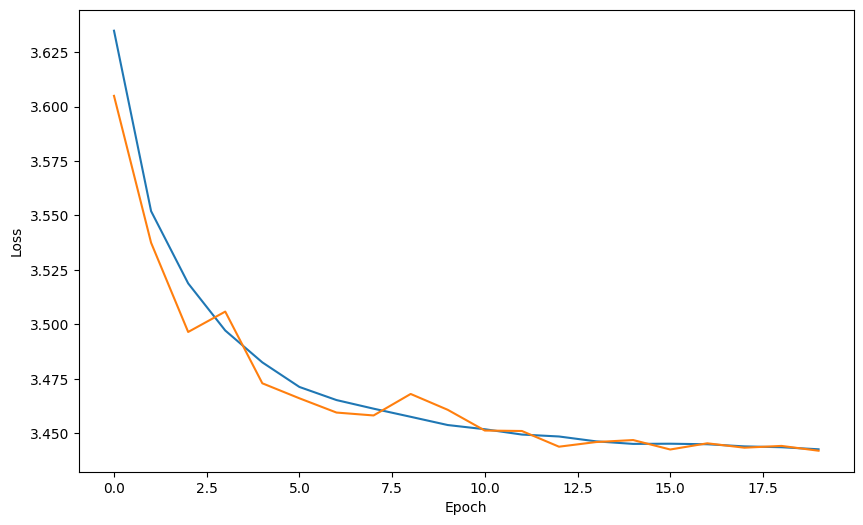

In [ ]:
fig = plt.figure(figsize=(10, 6))

plt.plot(range(EPOCHS), results["train_loss"])
plt.plot(range(EPOCHS), results["val_loss"])

plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.show()